In [2]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250713-naturalness-param-scan',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'BLAT_ECOLX_Firnberg_2014', 'HXK4_HUMAN_Gersing_2022_activity', 'SHOC2_HUMAN_Kwon_2022', 'CBS_HUMAN_Sun_2020', 'HSP82_YEAST_Flynn_2019', 'OXDA_RHOTO_Vanella_2023_activity', 'PPM1D_HUMAN_Miller_2022', 'ANCSZ_Hobbs_2022', 'HEM3_HUMAN_Loggerenberg_2023'}


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_96886/2292114737.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ESM2-150m vs. ESMC-300m: t-test paired samples, P_val:7.878e-03 t=2.719e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ESM2-150m vs. ESMC-300m: t-test paired samples, P_val:2.820e-02 t=-2.231e+00


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_96886/2292114737.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c[1] for c in model_name_list])
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_96886/2292114737.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_96886/2292114737.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_96886/2292114737.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after

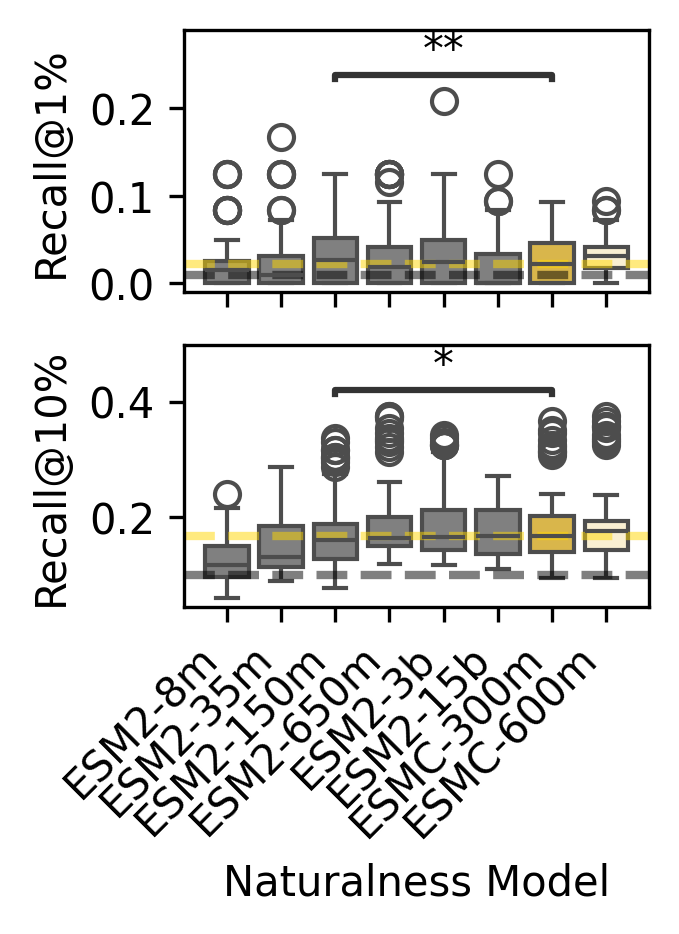

In [11]:
import re
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2, 2.5), sharex=True, dpi=300)

# PLOT_TYPE = 'scatter'
# PLOT_TYPE = 'bar'
PLOT_TYPE = 'boxplot'

model_name_list = [
    # ('FolDE-base', 'base'),
    ('FolDE-8m', 'ESM2-8m'),
    ('FolDE-35m', 'ESM2-35m'),
    ('FolDE-150m', 'ESM2-150m'),
    ('FolDE-650m', 'ESM2-650m'),
    ('FolDE-3b', 'ESM2-3b'),
    ('FolDE-15b', 'ESM2-15b'),
    ('FolDE-300m', 'ESMC-300m'),
    ('FolDE-600m', 'ESMC-600m'),
]

def name_to_size(name):
    if not re.match(r'.*-\d+[bm]', name):
        return 0.0
    sizestr = name.split('-')[1]
    size = float(sizestr[:-1])
    if sizestr.endswith('b'):
        size *= 1e9
    elif sizestr.endswith('m'):
        size *= 1e6
    return size

model_name_map = {k: v for k, v in model_name_list}
initial_metrics_df = round_metrics_df[round_metrics_df.round_num == 1].copy()
initial_metrics_df = initial_metrics_df[initial_metrics_df.config_name.isin([c[0] for c in model_name_list])]

initial_metrics_df['model_name'] = initial_metrics_df.config_name.apply(lambda x: model_name_map[x])
initial_metrics_df['Model Family'] = initial_metrics_df.model_name.apply(lambda x: x.split('-')[0])
initial_metrics_df['Model Size'] = initial_metrics_df.model_name.apply(name_to_size)


for ii, (ax, metric) in enumerate(zip([ax1, ax2], ['held_out_1pct_recall', 'held_out_10pct_recall'])):
    grouped_df = initial_metrics_df.groupby(['model_name', 'round_num', 'Model Family', 'Model Size'])[metric].mean().reset_index()
    def get_color(model_name):
        if model_name.startswith('ESM2'):
            return 'grey'
        elif model_name == 'ESMC-300m':
            return '#F1C233'
        else:
            return '#FFF2CC'
    if PLOT_TYPE == 'scatter':
        sns.scatterplot(
            data=grouped_df,
            hue='model_name',
            x='Model Size',
            y=metric,
            ax=ax,
            s=20,
            palette={c[1]: get_color(c[1]) for c in model_name_list},
            legend=False,
        )
        ax.set_xscale('log')
    elif PLOT_TYPE == 'bar':
        sns.barplot(
            data=initial_metrics_df,
            x='model_name',
            y=metric,
            order=[c[1] for c in model_name_list],
            # hue='Model Family',
            palette={c[1]: get_color(c[1]) for c in model_name_list},
            ax=ax,
        )
    elif PLOT_TYPE == 'boxplot':
        sns.boxplot(
            data=initial_metrics_df,
            x='model_name',
            y=metric,
            order=[c[1] for c in model_name_list],
            # hue='Model Family',
            palette={c[1]: get_color(c[1]) for c in model_name_list},
            ax=ax,
        )
    else:
        assert False, PLOT_TYPE
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


    pairs = [
        ('ESM2-150m', 'ESMC-300m')
    ]

    # ax1_pairs = [
    #     ((methods[0], ), (methods[1], )),
    #     ((methods[1], ), (methods[2], )),
    # ]
    annot1 = Annotator(
        ax,
        pairs,
        data=initial_metrics_df,
        x='model_name',
        y=metric,
        order=[c[1] for c in model_name_list],
    )
    annot1.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
    annot1.apply_test()
    annot1.annotate()

    if PLOT_TYPE == 'bar' or PLOT_TYPE == 'scatter':
        baseline_y = initial_metrics_df[initial_metrics_df.model_name == 'ESMC-300m'][metric].mean()
    else:
        baseline_y = initial_metrics_df[initial_metrics_df.model_name == 'ESMC-300m'][metric].median()

    ax.axhline(
        y=baseline_y,
        color='gold',
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label='FolDE'
    )
    ax.axhline(
        y=0.01 if metric == 'held_out_1pct_recall' else 0.1,
        color='black',
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label='Random Baseline'
    )

    if metric == 'held_out_1pct_recall':
        ax.set_ylabel('Recall@1%')
    elif metric == 'held_out_10pct_recall':
        ax.set_ylabel('Recall@10%')
    
    if PLOT_TYPE == 'scatter':
        ax.set_xticks([1e7, 1e8, 1e9, 1e10])
    else:
        ax.set_xticklabels([c[1] for c in model_name_list])
    
# ax1.get_legend().remove()

if PLOT_TYPE == 'scatter':
    ax2.set_xlabel('Embedding Model Size')
    ax2.legend(
        title='Model Family',
        loc='lower right',
        bbox_to_anchor=(0.85, -1.8),
        fontsize=8
    )
else:
    ax2.set_xlabel('Naturalness Model')




/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_23593/728580424.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


Text(0, 0.5, 'Recall@10% of Held-Out Mutants')

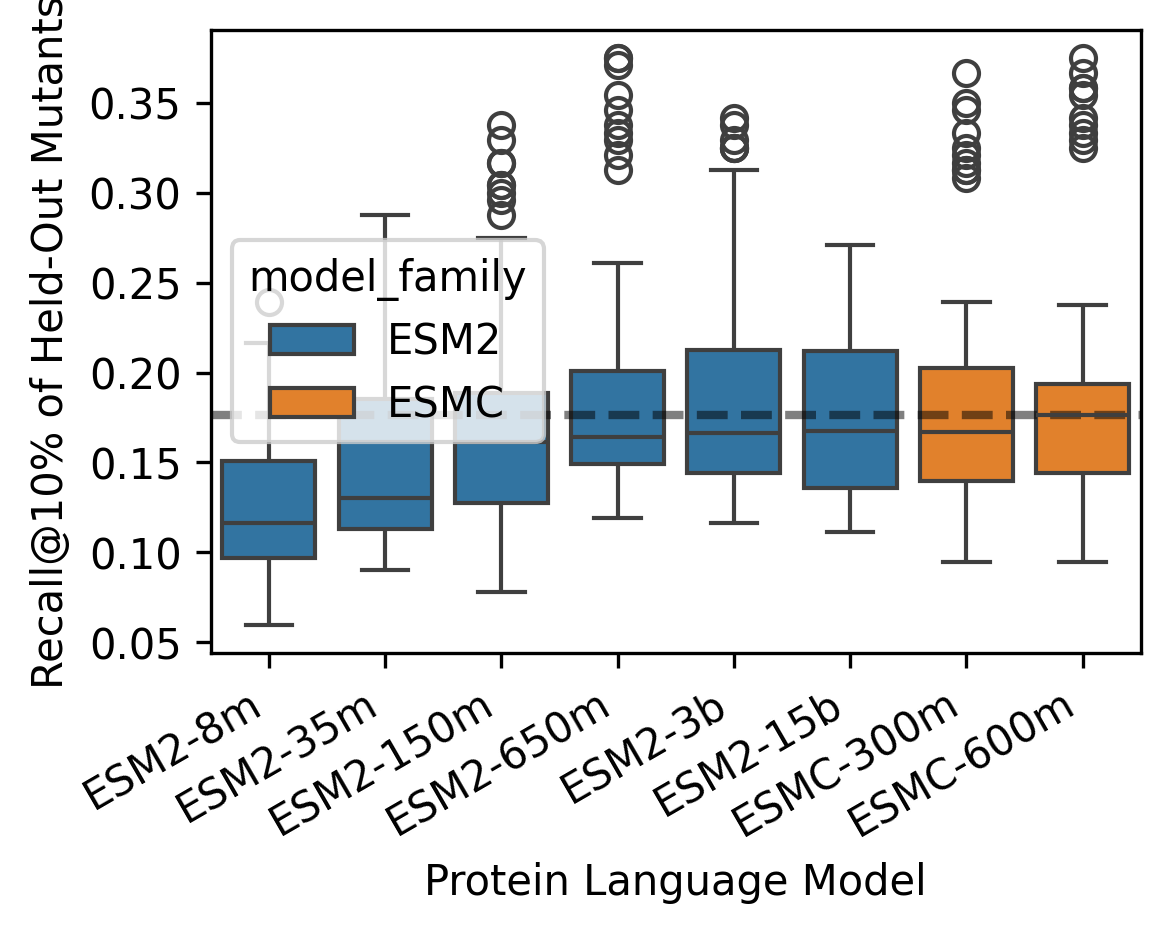

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

METRIC = 'held_out_10pct_recall'

model_name_list = [
    ('FolDE-base', 'base'),
    ('FolDE-8m', 'ESM2-8m'),
    ('FolDE-35m', 'ESM2-35m'),
    ('FolDE-150m', 'ESM2-150m'),
    ('FolDE-650m', 'ESM2-650m'),
    ('FolDE-3b', 'ESM2-3b'),
    ('FolDE-15b', 'ESM2-15b'),
    ('FolDE-300m', 'ESMC-300m'),
    ('FolDE-600m', 'ESMC-600m'),
]
model_name_map = {k: v for k, v in model_name_list}
initial_metrics_df = round_metrics_df[round_metrics_df.round_num == 1].copy()
initial_metrics_df['model_name'] = initial_metrics_df.config_name.apply(lambda x: model_name_map[x])
initial_metrics_df['model_family'] = initial_metrics_df.model_name.apply(lambda x: x.split('-')[0])

plt.figure(figsize=(4, 2.7), dpi=300)
ax = sns.boxplot(
    data=initial_metrics_df[
        (initial_metrics_df.model_name != 'base')
    ],
    x='model_name',
    y=METRIC,
    order=[v for k, v in model_name_list[1:]],
    hue='model_family',
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

ax.axhline(
    y=initial_metrics_df[initial_metrics_df.model_name == 'ESMC-600m'][METRIC].median(),
    color='black',
    linestyle='--',
    linewidth=2,
    alpha=0.5,
    label='ESMC-600m median'
)

plt.xlabel('Protein Language Model')
plt.ylabel('Recall@10% of Held-Out Mutants')






